# Monte Carlo Tree Search (MCTS) : Baseline vs Fixed

Compare MCTS before and after implementation fixes:
- Child move selection based on the number of visits rather than UCB score
- rollOut reward scalled to [0, 1] (rather than up to 10) with a matching UCB constant
- Corrected backpropagation on node expansion for update counts and scores
- Correct scoring for terminal nodes (Games won or lost) rather than a fixed constant score

**Experimental Design:**
- **Unpaired Samples:** MCTS games diverge from the same starting position, so no shared position to pair on. Baseline and fixed runs are treated as independent samples.
- **Sample Size:** 100 games for each configuration (baseline and fixed). Against opponents: 
  - Random player
  - Alpha Beta Prunning player (depths: 3, 4, 5)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style="whitegrid")
%matplotlib inline

# 1. Load Data and Combine 

In [32]:
# File dictionary. Keys: (opponent, depth, phase), Values: path to CSV file
FILES = {
    ("random", None, "baseline"): "./../results/mcts_vs_random_baseline.csv",
    ("random", None, "fixed"):    "./../results/mcts_vs_random_fixed.csv",
    ("alphabeta", 3, "baseline"): "./../results/mcts_vs_alphabeta_baseline3.csv",
    ("alphabeta", 4, "baseline"): "./../results/mcts_vs_alphabeta_baseline4.csv",
    ("alphabeta", 5, "baseline"): "./../results/mcts_vs_alphabeta_baseline5.csv",
    ("alphabeta", 3, "fixed"):    "./../results/mcts_vs_alphabeta_fixed3.csv",
    ("alphabeta", 4, "fixed"):    "./../results/mcts_vs_alphabeta_fixed4.csv",
    ("alphabeta", 5, "fixed"):    "./../results/mcts_vs_alphabeta_fixed5.csv",
}

frames = []

for (opponent, depth, phase), path in FILES.items():
    # For each dictionary entry read the csv
    d = pd.read_csv(path)
    # Add the opponent, depth and phase columns to a temporary dataframe
    d["opponent"] = opponent
    d["depth"] = depth
    d["phase"] = phase

    frames.append(d)

# Concatenate all the temporary dataframes into a single dataframe along the rows
df = pd.concat(frames, ignore_index=True)

# New columns added


_mcts_won = df["winner"] == df["mcts_colour"]
_is_draw = df["winner"] == "NoColour"

df["outcome"] = np.select(
    [
        _mcts_won,
        _is_draw & (df["moves"] < 80),
        _is_draw & (df["moves"] >= 80)
    ],
    [
        "win",
        "draw_repetition",
        "draw_timeout"
    ],
    default="loss"
)

df["mcts_won"] = df["outcome"] == "win"
df["opponent_won"] = df["outcome"] == "loss"
df["not_loss"] = df["outcome"] != "loss"

display(df.head())

,game_index,mcts_colour,winner,moves,opponent,depth,phase,outcome,mcts_won,opponent_won,not_loss
0,0,Black,Black,48,random,None,baseline,win,True,False,True
1,1,White,White,49,random,None,baseline,win,True,False,True
2,2,Black,Black,42,random,None,baseline,win,True,False,True
3,3,White,White,31,random,None,baseline,win,True,False,True
4,4,Black,Black,42,random,None,baseline,win,True,False,True


# 2. Outcome Summary

Raw win/loss/draw counts for each condition. Win rates are ar at or near zero, which motivates the focus on `non_loss_rate` in the next statstical tests as the primary comparison. The changes made to the MCTS were not meant to improve win rate, but rather to improve the quality of the search and making it a harder opponent to beat.

In [33]:
summary = df.groupby(["opponent", "depth", "phase"], dropna=False).agg(
    n=("outcome", "size"),
    wins=("mcts_won", "sum"),
    draws_repetition=("outcome", lambda x: (x == "draw_repetition").sum()),
    draws_timeout=("outcome", lambda x: (x == "draw_timeout").sum()),
    losses=("opponent_won", "sum"),
    win_rate=("mcts_won", "mean"),
    non_loss_rate=("not_loss", "mean"),
    median_moves=("moves", "median"),
).reset_index()

display(summary)

,opponent,depth,phase,n,wins,draws_repetition,draws_timeout,losses,win_rate,non_loss_rate,median_moves
0,alphabeta,3.0,baseline,100,3,23,33,41,0.03,0.59,71.5
1,alphabeta,3.0,fixed,100,18,23,44,15,0.18,0.85,77.5
2,alphabeta,4.0,baseline,100,0,9,32,59,0.00,0.41,67.0
3,alphabeta,4.0,fixed,100,4,15,46,35,0.04,0.65,78.0
4,alphabeta,5.0,baseline,100,0,7,21,72,0.00,0.28,63.0
5,alphabeta,5.0,fixed,100,1,15,46,38,0.01,0.62,77.5
6,random,NaN,baseline,100,95,0,5,0,0.95,1.00,42.0
7,random,NaN,fixed,100,100,0,0,0,1.00,1.00,41.0


# 3. Statistical Tests

Conducted Fisher's exact test on 2x2 win/loss and non-loss/loss contingency tables. Fisher's test was used rather than a Chi-Squared test because several cells have small counts.

For testing a change in the number of moves to a decisive outcome, games that have not reached a decisive outcome in 80 moves are excluded. Mann-Whitney U test was used as move counts are unlikely to be normally distributed.

In [46]:
results = []

for depth in [None, 3, 4, 5]:
    # For each opponent, select the baseline and fixed dataframes
    opp = "random" if depth is None else "alphabeta"
    depth_mask = df["depth"] == depth if depth is not None else df["depth"].isna()


    baseline = df[(df["opponent"] == opp) & depth_mask & (df["phase"] == "baseline")]
    fixed = df[(df["opponent"] == opp) & depth_mask & (df["phase"] == "fixed")]

    # Table for Fisher's exact test for win rates
    table_win = [
        [baseline["mcts_won"].sum(), (~baseline["mcts_won"]).sum()],
        [fixed["mcts_won"].sum(), (~fixed["mcts_won"]).sum()]
    ]

    _, p_win = stats.fisher_exact(table_win)

    # Table for Fisher's exact test for non-loss rates
    table_non_loss = [
        [baseline["not_loss"].sum(), (~baseline["not_loss"]).sum()],
        [fixed["not_loss"].sum(), (~fixed["not_loss"]).sum()]
    ]

    _, p_non_loss = stats.fisher_exact(table_non_loss)

    # Selecting only the moves from non-draw-timeout games for both baseline and fixed conditions
    baseline_moves = baseline[baseline["outcome"] != "draw_timeout"]["moves"]
    fixed_moves = fixed[fixed["outcome"] != "draw_timeout"]["moves"]

    if len(baseline_moves) > 0 and len(fixed_moves) > 0:
        # Perform Mann-Whitney U test to compare the distributions of moves
        u_stat, p_moves = stats.mannwhitneyu(baseline_moves, fixed_moves, alternative='two-sided')
        median_moves_baseline = baseline_moves.median()
        median_moves_fixed = fixed_moves.median()
    else:
        p_moves = np.nan
        median_moves_baseline = np.nan
        median_moves_fixed = np.nan

    results.append({
        "opponent": opp,
        "depth": depth,
        "win_rate_baseline": baseline["mcts_won"].mean(),
        "win_rate_fixed": fixed["mcts_won"].mean(),
        "win_rate_p_value": p_win,
        "non_loss_rate_baseline": baseline["not_loss"].mean(),
        "non_loss_rate_fixed": fixed["not_loss"].mean(),
        "non_loss_rate_p_value": p_non_loss,
        "median_moves_baseline": median_moves_baseline,
        "median_moves_fixed": median_moves_fixed,
        "median_moves_p_value": p_moves
    })

# Create a DataFrame from the results list and set a MultiIndex for better organization and readability
statistical_results = pd.DataFrame(results).set_index(["opponent", "depth"])
statistical_results.columns = pd.MultiIndex.from_tuples([
    ("win_rate", "baseline"), ("win_rate", "fixed"), ("win_rate", "p_value"),
    ("non_loss_rate", "baseline"), ("non_loss_rate", "fixed"), ("non_loss_rate", "p_value"),
    ("moves", "baseline"), ("moves", "fixed"), ("moves", "p_value"),
])
display(statistical_results)


win_rate                 non_loss_rate                  \
                baseline fixed   p_value      baseline fixed   p_value   
opponent  depth                                                          
random    NaN       0.95  1.00  0.059383          1.00  1.00  1.000000   
alphabeta 3.0       0.03  0.18  0.000820          0.59  0.85  0.000067   
          4.0       0.00  0.04  0.121241          0.41  0.65  0.001068   
          5.0       0.00  0.01  1.000000          0.28  0.62  0.000002   

                   moves                  
                baseline fixed   p_value  
opponent  depth                           
random    NaN       42.0  41.0  0.013222  
alphabeta 3.0       65.0  67.5  0.096492  
          4.0       57.5  64.0  0.009482  
          5.0       56.0  67.0  0.000391

# 4. Plots

### 4a. Non-Loss Rate vs Opponent Strength

How often MCTS avoids loosing, baseline vs fixed, as the alpha-beta opponent's search depth increases. The fixed MCTS is more robust to the stronger opponent, with a higher non-loss rate at all depths.

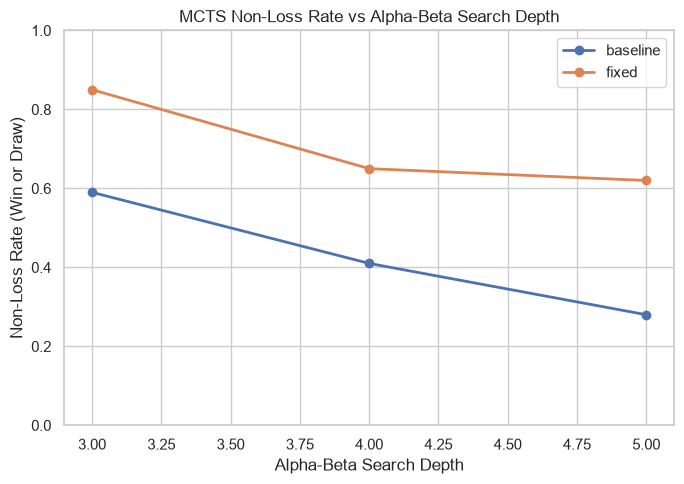

In [ ]:
# Subset the summary dataframe for only the alpha-beta opponent
alphabeta = summary[summary["opponent"] == "alphabeta"]

fig, ax = plt.subplots(figsize=(7, 5))

for phase in ["baseline", "fixed"]:
    # Subset the alphabeta dataframe for the current phase and sort by depth
    sub = alphabeta[alphabeta["phase"] == phase].sort_values("depth")
    # Plot the non-loss rate against depth for the current phase
    ax.plot(sub["depth"], sub["non_loss_rate"], marker="o", label=phase, linewidth=2)

ax.set_xlabel("Alpha-Beta Search Depth")

ax.set_ylabel("Non-Loss Rate (Win or Draw)")
ax.set_ylim(0, 1)

ax.set_title("MCTS Non-Loss Rate vs Alpha-Beta Search Depth")

ax.legend()

plt.tight_layout()
plt.savefig("./figures/non_loss_rate_vs_depth.png", dpi=150)
plt.show()

### 4b. Win/Draw/Loss Breakdown vs Opponent Strength

Breakdown of the game outcome based on the alpha-beta opponent's search depth. Excludes games that have not reached a decisive outcome in 80 moves.

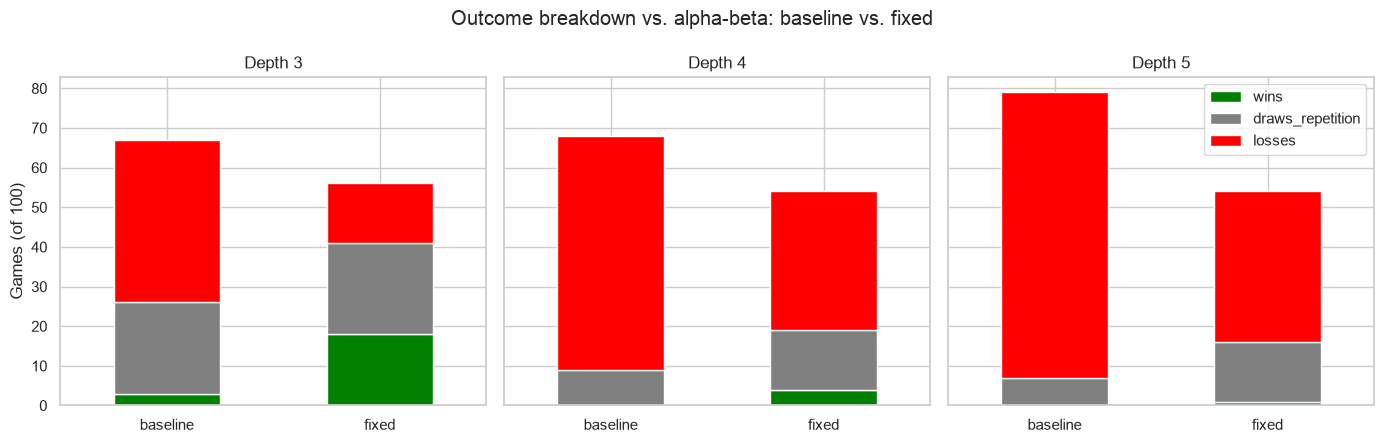

In [36]:
# Subset the summary dataframe for only the alphabeta opponent
alphabeta = summary[summary["opponent"] == "alphabeta"]

# Initialise a figure with 1 row and 3 columns of subplots
# sharey=True ensures that all subplots share the same y-axis scale
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, depth in zip(axes, [3, 4, 5]):

    sub = alphabeta[alphabeta["depth"] == depth].set_index("phase")[["wins", "draws_repetition", "losses"]]
    sub = sub.loc[["baseline", "fixed"]]
    sub.plot(kind="bar", stacked=True, ax=ax, legend=(depth == 5),
              color=["green", "grey", "red"])
    
    ax.set_title(f"Depth {depth}")
    
    # Must set y label only for the first subplot
    ax.set_ylabel("Games (of 100)" if depth == 3 else "")

    ax.set_xlabel("")

    # Set x-axis tick labels to be horizontal
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Outcome breakdown vs. alpha-beta: baseline vs. fixed")

plt.tight_layout()
plt.savefig("./figures/outcome_breakdown.png", dpi=150)
plt.show()

### 4c. Number of Moves to Decisive Outcome vs Opponent Strength

Distribution of game lengths (in moves) to a decisive outcome, baseline vs fixed, as the alpha-beta opponent's search depth increases. Excludes games that have not reached a decisive outcome in 80 moves.

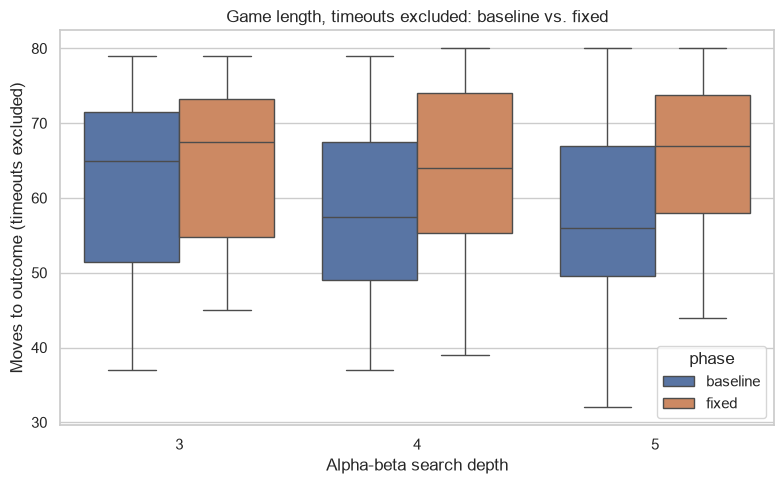

In [37]:
# Select only the decisive games (wins or losses) against the alphabeta opponent
defined_outcomes = df[(df["outcome"] != "draw_timeout") & (df["opponent"] == "alphabeta")]

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=defined_outcomes, x="depth", y="moves", hue="phase", ax=ax)

ax.set_xlabel("Alpha-beta search depth")

ax.set_ylabel("Moves to outcome (timeouts excluded)")

ax.set_title("Game length, timeouts excluded: baseline vs. fixed")

plt.tight_layout()
plt.savefig("./figures/moves_to_decisive.png", dpi=150)
plt.show()

# TODO

* Summary about the results and what they mean for the MCTS implementation.
* Benchmark on time